# Projet E - Malliavin Calculus
## Partie C : Étude Numérique – Option Asiatique (Modèle de Bachelier)
Nous sommes à la partie C du projet, la partie numérique.
Ce que nous allons faire :
- Méthode de Monte Carlo
- Étude de convergence
- Comparaison des méthodes de FD et IBD
### PARAMÈTRES DU MODÈLE ET IMPORTS

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd



# Les paramètres
x_0 = 100.0          # Condition initiale
r = 0.10             # Taux sans risque (10%)
T = 1.0              # Maturité (1 an)
barriere = 110.0     # Seuil
strike = 100.0       # Prix d'exercice du call


M_values = np.array([10, 20, 50, 100, 150, 250])   # Grille de pas de temps
N_simulations = np.arange(1000, 51001, 2000)


# Réglage de l'aléa.
np.random.seed(61)

### SIMULATION ET ESTIMATEURS DE GREEKS
Exécute la modélisation de Monte Carlo pour évaluer le prix et le Delta 
de l'option asiatique complexe dans le modèle de Bachelier.
Compare la méthode des différences finies (FD) et de Malliavin (IBP).

In [22]:
def simulate_bachelier_greeks(M, N):

    dt = T / M
    grille_temps = np.linspace(0, T, M+1)
    

    ### Génération des trajectoires ###
    dW = np.random.normal(0, np.sqrt(dt), (N, M))
    W = np.concatenate((np.zeros((N, 1)), np.cumsum(dW, axis=1)), axis=1)
    
    # Bachelier
    X = x_0 + W
    
    # Intégration
    integral_X = (T/M) * np.sum(X, axis=1)
    
    # Évaluation du Payoff
    indicator = (integral_X < barriere).astype(float)
    payoff_vanilla = np.maximum(X[:, -1] - strike, 0)
    payoff_total = indicator * payoff_vanilla
    
    # Actualisation sous la mesure risque neutre
    actualise = np.exp(-r * T) * payoff_total
    
    # Estimateur de Prix de Monte Carlo
    price_mc = np.mean(actualise)
    var_price = np.var(actualise, ddof=1)
    ic_price = 1.96 * np.sqrt(var_price / N)
    

    ### Méthodologie des Différences Finies (FD) ###
    epsilon = 0.1 
    
    # Trajectoire choc à la hausse
    X_up = (x_0 + epsilon) + W
    integral_X_up = (T/M) * np.sum(X_up, axis=1)
    payoff_up = (integral_X_up < barriere).astype(float) * np.maximum(X_up[:, -1] - strike, 0)
    
    # Trajectoire choc à la baisse
    X_down = (x_0 - epsilon) + W
    integral_X_down = (T/M) * np.sum(X_down, axis=1)
    payoff_down = (integral_X_down < barriere).astype(float) * np.maximum(X_down[:, -1] - strike, 0)
    
    # Estimateur Delta FD
    delta_fd_ech = np.exp(-r * T) * (payoff_up - payoff_down) / (2 * epsilon)
    delta_fd = np.mean(delta_fd_ech)
    var_fd = np.var(delta_fd_ech, ddof=1)
    ic_fd = 1.96 * np.sqrt(var_fd / N)
    

    ### Méthodologie du Calcul de Malliavin (IBP) ###
    t_grid = grille_temps[:-1]
    integral_s_dBs = np.sum(t_grid * dW, axis=1)
    
    Pi_weight = (4.0 / T) * W[:, -1] - (6.0 / (T**2)) * integral_s_dBs
    
    # Estimateur Delta IBP
    delta_ibp_ech = actualise * Pi_weight
    delta_ibp = np.mean(delta_ibp_ech)
    var_ibp = np.var(delta_ibp_ech, ddof=1)
    ic_ibp = 1.96 * np.sqrt(var_ibp / N)
    
    return {
        'price': price_mc, 'var_price': var_price, 'ic_price': ic_price,
        'delta_fd': delta_fd, 'var_fd': var_fd, 'ic_fd': ic_fd,
        'delta_ibp': delta_ibp, 'var_ibp': var_ibp, 'ic_ibp': ic_ibp
    }

### ANALYSE DE LA CONVERGENCE

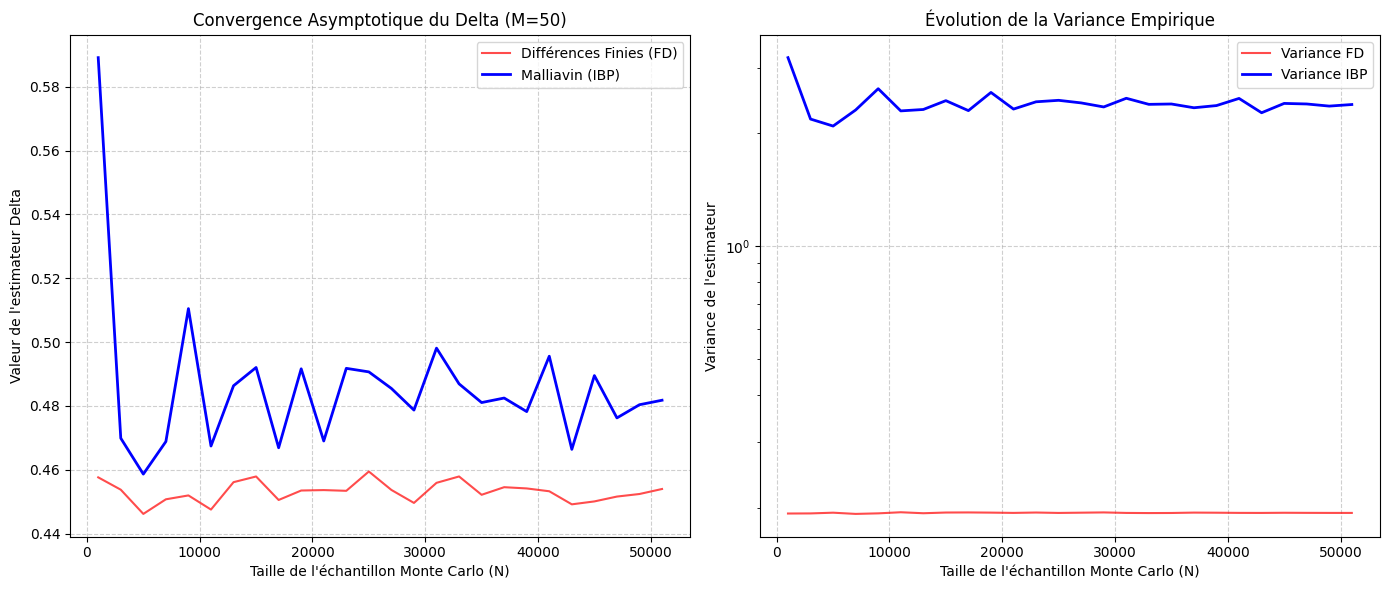

In [23]:
M_target = 50

# Collecte des mesures
results_price = []
results_delta_fd = []
results_var_fd = []
results_delta_ibp = []
results_var_ibp = []

for N in N_simulations:
    res = simulate_bachelier_greeks(M_target, N)
    results_price.append(res['price'])
    results_delta_fd.append(res['delta_fd'])
    results_var_fd.append(res['var_fd'])
    results_delta_ibp.append(res['delta_ibp'])
    results_var_ibp.append(res['var_ibp'])

# Affichage graphique
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(N_simulations, results_delta_fd, label="Différences Finies (FD)", color='red', alpha=0.7)
plt.plot(N_simulations, results_delta_ibp, label="Malliavin (IBP)", color='blue', linewidth=2)
plt.title(f"Convergence Asymptotique du Delta (M={M_target})")
plt.xlabel("Taille de l'échantillon Monte Carlo (N)")
plt.ylabel("Valeur de l'estimateur Delta")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(N_simulations, results_var_fd, label="Variance FD", color='red', alpha=0.7)
plt.plot(N_simulations, results_var_ibp, label="Variance IBP", color='blue', linewidth=2)
plt.title("Évolution de la Variance Empirique")
plt.xlabel("Taille de l'échantillon Monte Carlo (N)")
plt.ylabel("Variance de l'estimateur")
plt.yscale('log')  # Indispensable pour l'observation des écarts
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### ÉTUDE EN FONCTION DE $M$

In [24]:
data = []
for M_val in M_values:
    res = simulate_bachelier_greeks(M_val, 50000)
    data.append([M_val, res['price'], res['ic_price'], 
                 res['delta_fd'], res['var_fd'], 
                 res['delta_ibp'], res['var_ibp']])

df = pd.DataFrame(data, columns=['M', 'Prix', 'IC Prix', 'Delta FD', 'Var FD', 'Delta IBP', 'Var IBP'])
print(df.to_string(index=False))

  M     Prix  IC Prix  Delta FD   Var FD  Delta IBP  Var IBP
 10 0.020855 0.000832 -0.049658 0.260191  -0.040205 0.047868
 20 0.365542 0.004679  0.454838 0.193670   0.527707 2.602172
 50 0.358781 0.004627  0.450838 0.193797   0.471413 2.346153
100 0.363042 0.004663  0.452513 0.193733   0.477050 2.376727
150 0.367136 0.004690  0.455129 0.193674   0.476086 2.347645
250 0.358845 0.004607  0.450758 0.193699   0.457992 2.294223


### CONCLUSION

- **Convergence validée :** Les deux méthodes (FD et IBP) convergent vers une valeur de Delta cohérente (autour de 0.45 pour M=50).

- **Stabilité des Différences Finies :** L'estimateur FD est extrêmement robuste. Sa variance reste très faible et constante (environ 0.19).

- **Instabilité de Malliavin (IBP) :** La méthode IBP a une variance énorme (10x supérieure à FD, autour de 2.3 à 2.6). La convergence est donc très bruitée, même pour un grand nombre de trajectoires (N=50000).

**Bilan :** Dans notre cas, la méthode des Différences Finies est beaucoup plus performante. L'approche de Malliavin nécessite l'ajout de techniques de réduction de variance pour devenir meilleure.